# **Measure Organelle Interactions**

***Prior to this notebook, you should have already run through [2.0_quantification_setup](2.0_quantification_setup.ipynb).***

In notebooks 2.1 through 2.4, we will go over the implementation of `infer-subc` quantification methods (explained in detail in the `method_...` notebooks) to assess the morphology, interactions, and distribution of organelles at the single-cell level. 

### 📍 **Purpose**
This notebook can be used to measure the `interactions` -- the overlapping of two or more segmented `organelles` -- from one or more cells. It includes options to:
1. 🦠 Quantify the interactions of *two or more organelle(s)* from <ins>ONE CELL</ins>
2. 🧪 Batch process the interactions of *two or more organelle(s)* from *multiple cells* for a <ins>SINGLE EXPERIMENT</ins>
3. 🧮 Summarize interaction metrics *per cell* across <INS>ONE OR MORE EXPERIMENTS</ins>


### 🍃 **Biological Relevance - Organelle Interactions**
Intracellular organelles do not exist independently of one another. In recent years, the existance and function of organelle contact site, regions of close apposition between membrane bound organelles has been recognized. They facilitate protein, lipid, and metabolite transport, coordinate organelle trafficking and function, and are involved in many cellular pathways and functions [[1](https://www.cell.com/cell/pdf/S0092-8674(23)01328-4.pdf)]. 

The distance between membranes at contact sites is between 30-80 nm depending on the types of organelles involved. This distance is not resolvable using standard confocal microscopy images [[2](https://zeiss-campus.magnet.fsu.edu/articles/basics/resolution.html)]. However, interactions between organelle which can include organelle contact sites can be estimated through overlap in label localization in confocal microscopy images.

**`Organelle interaction sites`**: regions of overlap between two or more organelles

These sites can then be measured for features such as number, size, and shape utilizing the `get_morpholgy_metrics()` function outlined in [method_morphology](method_morphology.ipynb) and/or measurements of subcellular distribution utilizing the `get_distribution()` function outlined in [method_distribution](method_distribution.ipynb) notebook.

*You can learn more about how interaction sites are created within infer-subc in the [method_interactions](method_interactions.ipynb) notebook.*

-----

## 🗂️ **Table of Contents**
The following sections are included in this notebook:

**IMPORTS AND LOAD IMAGE**

**EXPLANATION OF STEPS** - This section serves as *expository examples* of the functions used to quantify, batch process, and summarize organelle interactions.

🦠 **Quantify *all organelle interaction types* from <ins>ONE IMAGE</ins>**
- **`STEP 1`** - Create a list of possible interaction types
- **`STEP 2`** - Loop through the list of possible interactions to quantify metrics for each
- **`STEP 3`** - Determine which interactions are novel interactions (not present in higher orders) in each type
- **`STEP 4`** - Add column to table for novel interactions
- **`DEFINE`** - The get_interaction_metrics_3D() function

🧪 **Batch process the quantification of *all possible organelle interaction types* from *multiple images* for a <ins>SINGLE EXPERIMENT</ins>**
- **`STEP 1`** - List images and segmentations to be collected for each image
- **`STEP 2`** - Loop through the list of images and perform the interaction quantification on all interaction types
- **`STEP 3`** - Combine all of the tables together and create/store the csv file
- **`DEFINE`** - The batch_process_interaction() function

🧮 **Summarize organelle interaction metrics *per cell* across <INS>ONE OR MORE EXPERIMENTS</ins>**
- **`STEP 1`** - Get the interaction .csv files
- **`STEP 2`** - Summarize the mean, median, and standard deviation of each feature per cell
- **`STEP 3`** - Calculate additional metrics
- **`STEP 4`** - Unstack the subregions, fill NA values with 0, and save file
- **`DEFINE`** - The batch_interaction_summary_stats() function

**EXECUTE QUANTIFICATION** - Once you understand how the functions work, this section can be used to quantify your data in a quick and easy way.
- **`STEP 1`:** 🧪 **Batch process the quantification of *all possible organelle interaction types* from *multiple cells* for a <ins>SINGLE EXPERIMENT</ins>**
- **`STEP 2`:** 🧮 **Summarize organelle interaction metrics *per cell* across <INS>ONE OR MORE EXPERIMENTS</ins>**

-----
---------------------
## **IMPORTS AND LOAD IMAGE**
Details about the functions included in this subsection are outlined in the [`2.0_quantification_setup`](2.0_quantification_setup.ipynb) notebook. Please visit that notebook first if you are confused about any of the code included here.

#### &#x1F3C3; **Run code; no user input required**

In [ ]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import itertools
import napari
from napari.utils.notebook_display import nbscreenshot
from skimage.measure import (regionprops_table)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.textpath import TextPath
plt.rcParams['figure.dpi']= 600

from infer_subc.core.file_io import (read_czi_image,
                                     import_inferred_organelle,
                                     list_image_files)

from infer_subc.core.img import *
#from infer_subc.utils.stats import make_dict
from infer_subc.utils.stats import (cell_finder,
                                    region_finder)
from infer_subc.utils.stats_helpers import *
from infer_subc.utils.visualization import plot_overlaps
from infer_subc.organelles import * 

##################
## Color Constants
##################
ORANGE = '#FFA500'
BOPBLUE = '#20ADF8'
MAROON = '#800000'
WHITE = '#FFFFFF'
BLACK = '#000000'

# Splitter Contstant
splitter = 'X'

%load_ext autoreload
%autoreload 2

In [ ]:
def make_dict(list_obj_names: list[str],
               list_obj_segs: list[np.ndarray]):
    organelle_segs = {}                                                     
    for idx, name in enumerate(list_obj_names):                                  
        if name == 'ER':                                                    
            organelle_segs[name]=(list_obj_segs[idx]>0).astype(np.uint16)        
        else:                                                       
            organelle_segs[name]=list_obj_segs[idx]
    return organelle_segs

#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify the following information about your data: `raw_img_type`, `data_root_path`, `raw_data_path`, `seg_data_path`, and `quant_data_path`.

In [ ]:
#### USER INPUT REQUIRED ###
raw_img_type = ".czi"
data_root_path = Path(os.path.expanduser("~")) / "Documents/Python_Scripts/Infer-subc"
raw_data_path = data_root_path / "raw_two"
seg_data_path = data_root_path / "out_two"
quant_data_path = data_root_path / "quant_two"


#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# Create the output directory to save the segmentation outputs in.
if not Path.exists(quant_data_path):
    Path.mkdir(quant_data_path)
    print(f"making {quant_data_path}")

# Create a list of the file paths for each image in the input folder. Select test image path.
raw_img_file_list = list_image_files(raw_data_path,raw_img_type)
pd.set_option('display.max_colwidth', None)
pd.DataFrame({"Image Name":raw_img_file_list})

,Image Name
0,C:\Users\Shannon\Documents\Python_Scripts\Infer-subc\raw_two\a24hrs-Ctrl_14_Unmixing.czi
1,C:\Users\Shannon\Documents\Python_Scripts\Infer-subc\raw_two\a48hrs-Ctrl + oleic acid_01_Unmixing.czi


#### &#x1F6D1; &#x270D; **User Input Required:**

Use the list above to specify which image you wish to analyze based on its index: `test_img_n`

In [ ]:
#### USER INPUT REQUIRED ###
test_img_n = 0

#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# Read in the image and metadata as an ndarray and dictionary from the test image selected above. 
test_img_name = raw_img_file_list[test_img_n]
img_data,meta_dict = read_czi_image(test_img_name)

# Define some of the metadata features.
channel_names = meta_dict['name']
meta = meta_dict['metadata']['aicsimage']
scale = meta_dict['scale']
channel_axis = meta_dict['channel_axis']
file_path = meta_dict['file_name']

print("Metadata information")
print(f"File path: {file_path}")
for i in list(range(len(channel_names))):
    print(f"Channel {i} name: {channel_names[i]}")
print(f"Scale (ZYX): {scale}")
print(f"Channel axis: {channel_axis}")

Metadata information
File path: C:\Users\Shannon\Documents\Python_Scripts\Infer-subc\raw_two\a24hrs-Ctrl_14_Unmixing.czi
Channel 0 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Nuclei_Jan22
Channel 1 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Lyso+405_Jan22
Channel 2 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Mito+405_Jan22
Channel 3 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Golgi+405_Jan22
Channel 4 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Peroxy+405_Jan22
Channel 5 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: ER+405_Jan22
Channel 6 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: BODIPY+405low_Jan22
Channel 7 name: 0 :: a24hrs-Ctrl_14_Unmixing-0 :: Residuals
Scale (ZYX): (0.3891184878080979, 0.07987165184837317, 0.07987165184837318)
Channel axis: 0


#### &#x1F6D1; &#x270D; **User Input Required:**

Specify the following information about the segmentation files: - `org_file_names`, `org_channels_ordered`, `regions_file_names`, `suffix_separator`, and `mask_name`.

In [ ]:
#### USER INPUT REQUIRED ###
org_file_names = ["lyso", "mito", "golgi", "perox", "ER", "LD"]
org_channels_ordered = [4,3,2,1,0,6]
regions_file_names = ["cell", "nuc", "soma", "neurites"]
subregions_file_names = ["soma", "neurites"]
suffix_separator = "-20230426_test_"
mask_name = "cell"
include_dist = True


#### &#x1F3C3; **Run code; no user input required**

In [ ]:
# find file paths for segmentations
all_suffixes = org_file_names + regions_file_names
filez = find_segmentation_tiff_files(file_path, all_suffixes, seg_data_path, suffix_separator)

# read the segmentation and masks/regions files into memory
organelle_segs = [read_tiff_image(filez[org]) for org in org_file_names]
organelle_segs = make_dict(list_obj_names = org_file_names, list_obj_segs = organelle_segs)

regions = [] 
regions_dict = {}
for m in regions_file_names:
    mfile = read_tiff_image(filez[m])
    regions.append(mfile)
    regions_dict[m] = mfile
    if m == mask_name:
        mask = mfile

# match the intensity channels to the segmentation files
intensities = [img_data[ch] for ch in org_channels_ordered]

# open viewer and add images
viewer = napari.Viewer()
for r, reg in enumerate(regions_file_names):
    viewer.add_image(regions[r],
                     scale=scale,
                     name=f"{reg} mask")

# colors = ["red", "bop orange", "yellow", "green", "blue", "cyan", "magenta", "bop purple"]
for o, org in enumerate(org_file_names):
    viewer.add_image(intensities[o],
                     scale=scale,
                     name=f"{org} intensity channel")
    viewer.add_labels(organelle_segs[org],
                      scale=scale,
                      name=f"{org} segmentation")
viewer.grid.enabled = True
viewer.reset_view()

print("The following matching files were found and can now be viewed in Napari:")
filez

09-Feb-25 13:18:45 - vispy    - WARNING  - QWindowsWindow::setGeometry: Unable to set geometry 1086x661+1530+213 (frame: 1104x708+1521+175) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 905x831+1528+206 (frame: 923x878+1519+168) margins: 9, 38, 9, 9 minimum size: 385x519 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=403,566 maxtrack=0,0)


The following matching files were found and can now be viewed in Napari:


{'raw': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/raw_two/a24hrs-Ctrl_14_Unmixing.czi'),
 'lyso': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_lyso.tiff'),
 'mito': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_mito.tiff'),
 'golgi': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_golgi.tiff'),
 'perox': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_perox.tiff'),
 'ER': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_ER.tiff'),
 'LD': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24hrs-Ctrl_14_Unmixing-20230426_test_LD.tiff'),
 'cell': WindowsPath('C:/Users/Shannon/Documents/Python_Scripts/Infer-subc/out_two/a24h

------
-----
## **EXPLANATION OF STEPS**

-----
### 🔗 **Quantify *two or more organelles overlaps* from <ins>ONE INTERACTION TYPE</ins>**

Listing out all combos of organelles

In [ ]:
all_pos =[]
for n in list(map(lambda x:x+2, (range(len(org_file_names)-1)))):
    all_pos += itertools.combinations(org_file_names, n)
possib = [splitter.join(inter) for inter in all_pos]

print(list(enumerate(possib)))

Choose which combo to use from above list

In [ ]:
overlap_orgs = 17

Print out string for chosen overlap

In [ ]:
overlap_orgs = possib[overlap_orgs]
print(overlap_orgs)

#### **`STEP 1`** - Loop through list of organelles involved in the interaction to add to overlap

In [ ]:
site = np.ones_like(organelle_segs[overlap_orgs.split(splitter)[0]])
for org in overlap_orgs.split(splitter):
    b = organelle_segs[org]             
    valid = (b>0)*(site>0)
    digit = len(str(np.max(site)))      
    site = (b*(10**(digit)))+site       
    site[valid.astype(bool)==False]=0   
    site = label(site)          

#### **`STEP 2`** - Apply Cell Mask

In [ ]:
site = apply_mask(site, mask)

#### **`STEP 3`** - Run Regionprops

In [ ]:
##########################################
## CREATE LIST OF REGIONPROPS MEASUREMENTS
##########################################
# start with LABEL
properties = ["label"]

# add position
properties += ["centroid", "bbox"]

# add area
properties += ["area", "equivalent_diameter"] # "num_pixels", 

# add shape measurements - NOTE: can't include minor axis measure because some of the contact sites are only one pixel
properties += ["extent", "euler_number", "solidity", "axis_major_length", "slice"] # "feret_diameter_max",  , "axis_minor_length"
    

##################
## RUN REGIONPROPS
##################
props = regionprops_table(site, 
                          intensity_image=None, 
                          properties=properties, 
                          extra_properties=None, 
                          spacing=scale)

#### **`STEP 4`** - Determine locations of overlaps

In [ ]:
cells = cell_finder(scale=scale, obj=site, mask=mask, props=props)
subregions = region_finder(scale=scale, obj=site, regions=regions_dict, props=props)

#### **`STEP 5`** - Determine surface area of overlaps

In [ ]:
##################################################################
## RUN SURFACE AREA FUNCTION SEPARATELY AND APPEND THE PROPS_TABLE
##################################################################
surface_area_tab = pd.DataFrame(surface_area_from_props(site, props, scale))

#### **`STEP 6`** - Determine organelles involved in overlaps by ID

In [ ]:
########################################################
## LIST WHICH ORGANELLES ARE INVOLVED IN THE INTERACTION
########################################################
over_inv = []
involved = overlap_orgs.split(splitter)
indexes = {overlap_orgs: []}
for index, l in enumerate(props["label"]):
        over_inv.clear()
        for org in involved:
            volume = site[props["slice"][index]]
            lorg = organelle_segs[org][props["slice"][index]]
            volume = volume==l
            lorg = lorg[volume]                                 
            all_inv = np.unique(lorg[lorg>0]).tolist()          
            if len(all_inv) != 1:
                print(f"we have an error.  as-> {all_inv}")
            over_inv.append(f"{all_inv[0]}")
        indexes[overlap_orgs].append('_'.join(over_inv))


#### **`STEP 6`** - Table Columns

In [ ]:
##################################################
## CREATE COMBINED DATAFRAME OF THE QUANTIFICATION
##################################################
props_table = pd.DataFrame(props)
props_table.rename(columns={'label': 'idx'}, inplace=True)
props_table.drop(columns=['slice'], inplace=True)
props_table.insert(0, 'label',value=indexes[overlap_orgs])
props_table.insert(0, "object", overlap_orgs)
props_table.rename(columns={"area": "volume"}, inplace=True)
props_table.insert(11, "surface_area", surface_area_tab)
props_table.insert(13, "SA_to_volume_ratio", 
props_table["surface_area"].div(props_table["volume"]))
if scale is not None:
    round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
    props_table.insert(loc=2, column="scale", value=f"{round_scale}")
else: 
    props_table.insert(loc=2, column="scale", value=f"{tuple(np.ones(site.ndim))}")
props_table.insert((props_table.columns.get_loc('object')+1), f'{mask_name}_number', value=cells)
props_table.insert((props_table.columns.get_loc(f'{mask_name}_number')+1), 'subregion', value=regions)

#### **`STEP 7`** - Run Distribution Metrics

In [ ]:
######################################################
## optional: DISTRIBUTION OF INTERACTION MEASUREMENTS
######################################################
if include_dist:
    interaction_dist_tab_list = []
    subregions = [mask_name] + list(regions_dict.keys())
    for region_name in subregions:
        centering_obj = dist_centering_obj[subregions.index(region_name)]
        if centering_obj != None:
            region_seg= regions[regions_file_names.index(region_name)]
            centering = regions[regions_file_names.index(centering_obj)]
            XY_interaction_dist, XY_bins, XY_wedges = get_XY_distribution(mask=mask, 
                                                                              mask_name=mask_name,
                                                                              obj=site,
                                                                              obj_name=overlap_orgs,
                                                                              region_seg=region_seg,
                                                                              region_name=region_name,
                                                                              centering_obj=centering,
                                                                              scale=scale,
                                                                              center_on=dist_center_on,
                                                                              keep_center_as_bin=dist_keep_center_as_bin,
                                                                              num_bins=dist_num_bins,
                                                                              zernike_degrees=dist_zernike_degrees)
                
            Z_interaction_dist = get_Z_distribution(mask=mask,
                                                        mask_name=mask_name,
                                                        obj=site,
                                                        region_seg=region_seg,
                                                        region_name=region_name,
                                                        obj_name=overlap_orgs,
                                                        center_obj=centering,
                                                        scale=scale)
            interaction_dist_tab_list.append(pd.merge(XY_interaction_dist, Z_interaction_dist, on=["object", "scale", f"{mask_name}_number", "subregion"]))

    interaction_dist_tab = pd.concat(interaction_dist_tab_list)
    indexes.clear()

#### **`DEFINE`** - interaction_metric_analysis() function

-----
### 🦠 **Quantify *all organelle interaction types* from <ins>ONE IMAGE</ins>**

#### **`STEP 1`** - Create a list of possible interaction types

#### **`STEP 2`** - Loop through each possible interactions to find metrics and determine novelty

#### **`STEP 3`** - Add column to table for interaction novelty

#### **`DEFINE`** - get_interaction_metrics_3D() function

# Quantify **Organelle Interactions** - part 2.2
--------------------
## **OBJECTIVE**
### <input type="checkbox"/> Quantify ***organelle interactions***
In this notebook, the logic for quantifying organelle **interaction composition** (how much of each interaction is present) and **morphology** (overlap site size and shape) is outlined.


---------
## **Organelle Interactions**

### summary of steps

🛠️ **BUILD FUNCTION PROTOTYPE**

- **`1`** - Examine how pair-wise overlappings are made

    - assemble list of pair-wise contacts

    - create overlapping regions between two organelle types

- **`2`** - Determine pair-wise overlappings that are present in triplet-wise overlaps (redundant overlaps)

    - iterate across all other organelle segmentations to find overlaps with the pair-wise overlapping region

    - watershed triplet-wise overlapping regions into pair-wise overlapping regions

- **`3`** - Use process for triplet-wise overlaps to make nth-wise overlaps 

    - assemble list of all possible contacts ranging from pair-wise to n-wise
    
    - iterate across n organelle types and create overlapping regions between them

- **`4`** - Expand on the method for finding redundant overlaps to find n-wise overlaps present in n+1 overlaps

    - iterate across all other organelle segmentations to find overlaps with the n-wise overlapping region

    - watershed n+1-wise overlaping regions into n-wise overlapping regions

- **`5`** - Build the list of measurements we want to include from regionprops and run regionprops

    - assemble list of measurements (morphological properties)

    - create initial regionprops table

- **`6`** - Track which individual organelles are involved in that interaction

    - identify labels involved in each unique interaction

    - correct and add measurements

⚙️ **EXECUTE FUNCTION PROTOTYPE**

- Define `_get_contact_metrics_3D` function
- Run `_get_contact_metrics_3D` function (scaled)
- Compare to finalized `get_contact_metrics_3D` function

## **IMPORTS**

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block loads all of the necessary python packages and functions you will need for this notebook.

## **LOAD AND READ IN IMAGE FOR PROCESSING**
> ###### 📝 **Specifically, this will include the raw image and the outputs from segmentation**

#### &#x1F6D1; &#x270D; **User Input Required:**

In [2]:
## Define the path to the directory that contains the input image folder.
data_root_path = Path(os.path.expanduser("~")) / "Documents/Python Scripts/Infer-subc-2D"

## Specify which subfolder that contains the input data and what the file type is. Ex) ".czi" or ".tiff"
in_data_path = data_root_path / "raw_single"
raw_img_type = ".tiff"

## Specify which subfolder contains the segmentation outputs and their file type
seg_data_path = data_root_path / "out_single"
seg_img_type = ".tiff"

## Specify the name of the output folder where quantification results will be saved
out_data_path = data_root_path / "quant_single"

## Specify which file you'd like to segment from the img_file_list
test_img_n = 0

## Specify the suffixes on the organelle segmentation files (i.e., the stuff following the "-")
org_names = ["lyso", "mito", "golgi", "perox", "ER", "LD"]

## Specify the suffixes on the region segmentation files (i.e., the stuff following the "-")
region_names = ["nuc", "cell"]

## Specify the organelles present in each channel of the raw image 
                ## syntax is {"organelle name": "channel number",...}
channel_orgs = {"lyso": 4,
                "mito": 3,
                "golgi": 2,
                "perox": 1,
                "ER": 0,
                "LD": 6,
                "nuc": 7,
                "PM": 5}

## Specify the suffix on the region segmentation file pertaining to the cell mask
mask = "cell"

## Specify the "splitter" that will be used between groupings of organelle names (i.e. lysoXmito)
splitter = "X"

#### &#x1F3C3; **Run code; no user input required**

In [3]:
if not Path.exists(out_data_path):
    Path.mkdir(out_data_path)
    print(f"making {out_data_path}")

raw_file_list = list_image_files(in_data_path, raw_img_type)
seg_file_list = list_image_files(seg_data_path, seg_img_type)
# pd.set_option('display.max_colwidth', None)
# pd.DataFrame({"Image Name":img_file_list})

In [4]:
raw_img_name = raw_file_list[test_img_n]

raw_img_data, raw_meta_dict = read_czi_image(raw_img_name)

channel_names = raw_meta_dict['name']
img = raw_meta_dict['metadata']['aicsimage']
scale = raw_meta_dict['scale']
channel_axis = raw_meta_dict['channel_axis']

In [5]:
org_segs = [import_inferred_organelle(org, raw_meta_dict, seg_data_path, seg_img_type) for org in org_names]
region_segs = [import_inferred_organelle(reg, raw_meta_dict, seg_data_path, seg_img_type) for reg in region_names]

loaded  inferred 3D `lyso`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `mito`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `golgi`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `perox`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `ER`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `LD`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `nuc`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 
loaded  inferred 3D `cell`  from C:\Users\zscoman\Documents\Python Scripts\Infer-subc-2D\out_single 


In [6]:
organelle_segs = {}                                                     
for idx, name in enumerate(org_names):                                  
    if name == 'ER':                                                    
        organelle_segs[name]=(org_segs[idx]>0).astype(np.uint16)        
    else:                                                       
        organelle_segs[name]=org_segs[idx]                      

In [7]:
mask_img = region_segs[region_names.index("cell")]

-----------------
Here we are defining an **organelle interaction** as any amount of pixel/voxel overlap between two organelles of different types. The overlap region will be know as the **interaction site**. We have implemented a pipeline that identifies two-way, three-way, and higher order contacts as well. This pipeline additionally distinguishes whether a contact is present in a higher order contact or not. Finally, the method for identifying individual contacts in this pipeline enables the use of "declumped" organelle segmentations.

We will utilize similar regionprops measurements as was done to quantify organelle and cell regions morphology.

> ###### 📝 **Since organelle contact sites are smaller than our resolution limit for confocal microscopy, the region of overlap is only an estimation of contacts. It may be helpful to dilate a single organelle (the organelle of interest) before determining the overlap region. This will include any touching, but not overlapping interactions and may improve our ability to detect differences in this subresolution system**

# ***BUILD FUNCTION PROTOTYPE***

## **`1` - Examine how 2-Way overlappings are made**

**aXb**: organelle a overlapping with organelle b (*NOTE: aXb and bXa overlaps are redundant*)

- assemble list of pair-wise contacts

In [8]:
paircomb = itertools.combinations(org_names, 2)
pairs = [splitter.join(inter) for inter in paircomb]
print(enumerate(pairs))

#### &#x1F6D1; &#x270D; **User Input Required:**

In [9]:
# Enter the organelles in the desired pair
orgA = "ER"
orgB = "golgi"

#### &#x1F3C3; **Run code; no user input required**

- create overlapping regions between two organelle types

In [10]:
# Creating desired overlap regions
a = organelle_segs[orgA]        #collects organelle a
b = organelle_segs[orgB]        #collects organelle b
c = (a>0)*(b>0)                 #determines true overlapping area without labels
digit = len(str(np.max(a)))     #finds number of digits in largest valued label of organelle a segmentation
overlap = (b*(10**(digit+1)))+a #assigns unique labels to each overlap
overlap[c==False] = 0           #ensures that locations with no overlap are labeled as 0
overlap = label(overlap)        #simplifies labels

- visualize segmentations 'a' and 'b'

28-Jan-25 12:51:41 - vispy    - WARNING  - QWindowsWindow::setGeometry: Unable to set geometry 1280x1136+12+46 (frame: 1302x1192+1+1) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 1280x1050+12+46 (frame: 1302x1106+1+1) margins: 11, 45, 11, 11 minimum size: 385x491 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=792,1038 maxtrack=0,0)
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


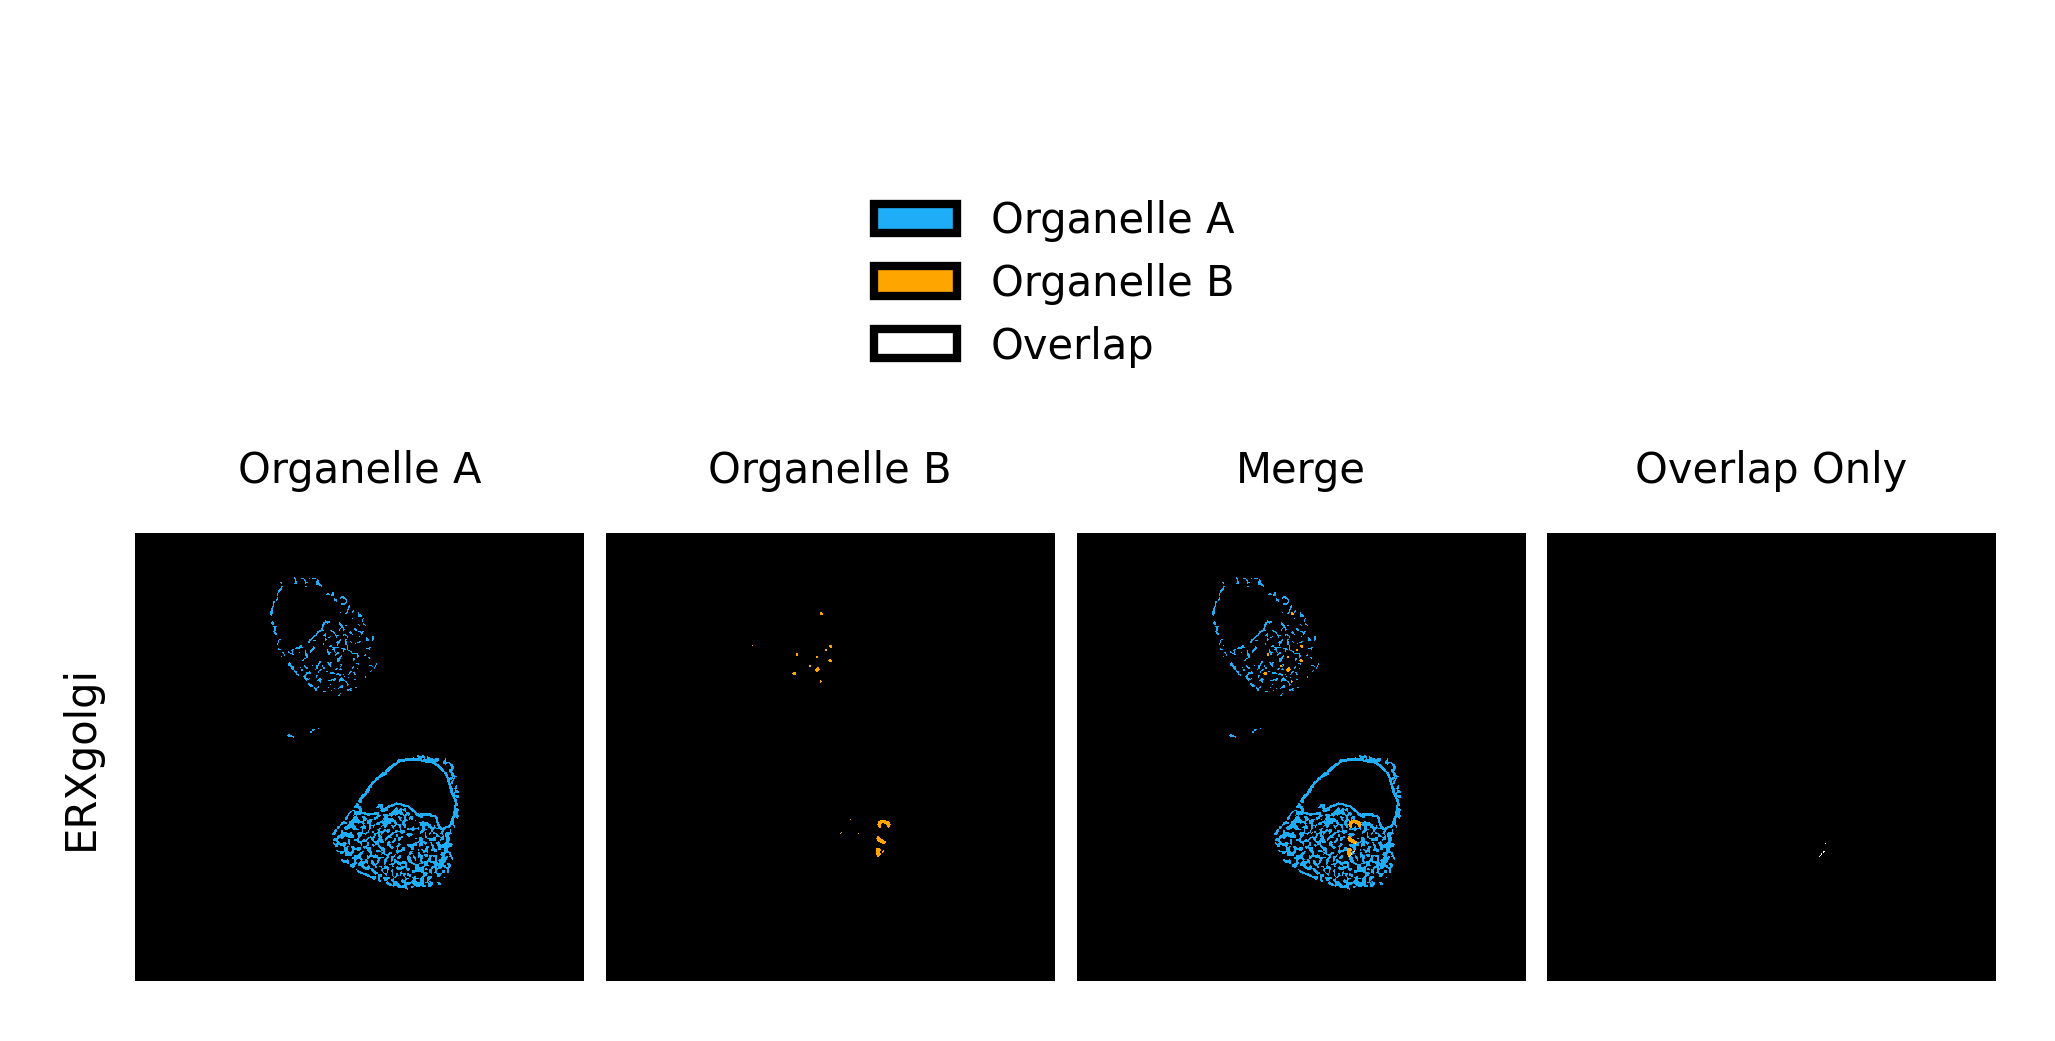

In [11]:
plot_overlaps(orgs=(orgA+splitter+orgB), splitter=splitter, organelle_segs=organelle_segs, scale=scale, close=False, holo=False)

## **`3` - Generate nth order overlaps based off of higher order overlap function**

- assemble list of possible contacts

be clear that the method above can be used for more than 2 orgs if desired

In [12]:
all_pos =[]
for n in list(map(lambda x:x+2, (range(len(org_names)-1)))):
    all_pos += itertools.combinations(org_names, n)
possib = [splitter.join(inter) for inter in all_pos]

print(list(enumerate(possib)))

[(0, 'lysoXmito'), (1, 'lysoXgolgi'), (2, 'lysoXperox'), (3, 'lysoXER'), (4, 'lysoXLD'), (5, 'mitoXgolgi'), (6, 'mitoXperox'), (7, 'mitoXER'), (8, 'mitoXLD'), (9, 'golgiXperox'), (10, 'golgiXER'), (11, 'golgiXLD'), (12, 'peroxXER'), (13, 'peroxXLD'), (14, 'ERXLD'), (15, 'lysoXmitoXgolgi'), (16, 'lysoXmitoXperox'), (17, 'lysoXmitoXER'), (18, 'lysoXmitoXLD'), (19, 'lysoXgolgiXperox'), (20, 'lysoXgolgiXER'), (21, 'lysoXgolgiXLD'), (22, 'lysoXperoxXER'), (23, 'lysoXperoxXLD'), (24, 'lysoXERXLD'), (25, 'mitoXgolgiXperox'), (26, 'mitoXgolgiXER'), (27, 'mitoXgolgiXLD'), (28, 'mitoXperoxXER'), (29, 'mitoXperoxXLD'), (30, 'mitoXERXLD'), (31, 'golgiXperoxXER'), (32, 'golgiXperoxXLD'), (33, 'golgiXERXLD'), (34, 'peroxXERXLD'), (35, 'lysoXmitoXgolgiXperox'), (36, 'lysoXmitoXgolgiXER'), (37, 'lysoXmitoXgolgiXLD'), (38, 'lysoXmitoXperoxXER'), (39, 'lysoXmitoXperoxXLD'), (40, 'lysoXmitoXERXLD'), (41, 'lysoXgolgiXperoxXER'), (42, 'lysoXgolgiXperoxXLD'), (43, 'lysoXgolgiXERXLD'), (44, 'lysoXperoxXERXLD

#### &#x1F6D1; &#x270D; **User Input Required:**



In [14]:
#Enter desired interaction's number (as shown in the above output)
number = 17

#### &#x1F3C3; **Run code; no user input required**
- iterate across n organelles and isolate the overlapping between all of them

In [15]:
orgs = possib[number]
site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
for org in orgs.split(splitter):        #iterates across organelles within the interaction
    b = organelle_segs[org]             #selects for iterated organelle
    valid = (b>0)*(site>0)              #isolates to only the locations where there are overlaps
    digit = len(str(np.max(site)))      #finds number of digits in largest valued label of organelle a segmentation
    site = (b*(10**(digit)))+site       #assigns unique labels to each overlap
    site[valid.astype(bool)==False]=0   #ensures that locations with no overlap are labeled as 0
    site = label(site)                  #simplifies labels

- create the function

In [16]:
def _create_overlap(orgs:str,
                    organelle_segs: dict[str:np.ndarray],
                    splitter: str="X") -> tuple[np.ndarray, np.ndarray]: 
    ##########################################
    ## CREATE OVERLAP
    ##########################################
    site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
    for org in orgs.split(splitter):
        b = organelle_segs[org]             
        valid = (b>0)*(site>0)
        digit = len(str(np.max(site)))      
        site = (b*(10**(digit)))+site       
        site[valid.astype(bool)==False]=0   
        site = label(site)             
    return site

- visualize segmentations 'a', 'b', and 'c' with the interactions between all 3 organelles visualized in white

# make clear that you are specifically talking about type of contact and num of orgs involved correctly!!!

28-Jan-25 12:57:44 - vispy    - WARNING  - QWindowsWindow::setGeometry: Unable to set geometry 1280x1136+12+46 (frame: 1302x1192+1+1) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 1280x1050+12+46 (frame: 1302x1106+1+1) margins: 11, 45, 11, 11 minimum size: 385x491 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=792,1038 maxtrack=0,0)
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napar

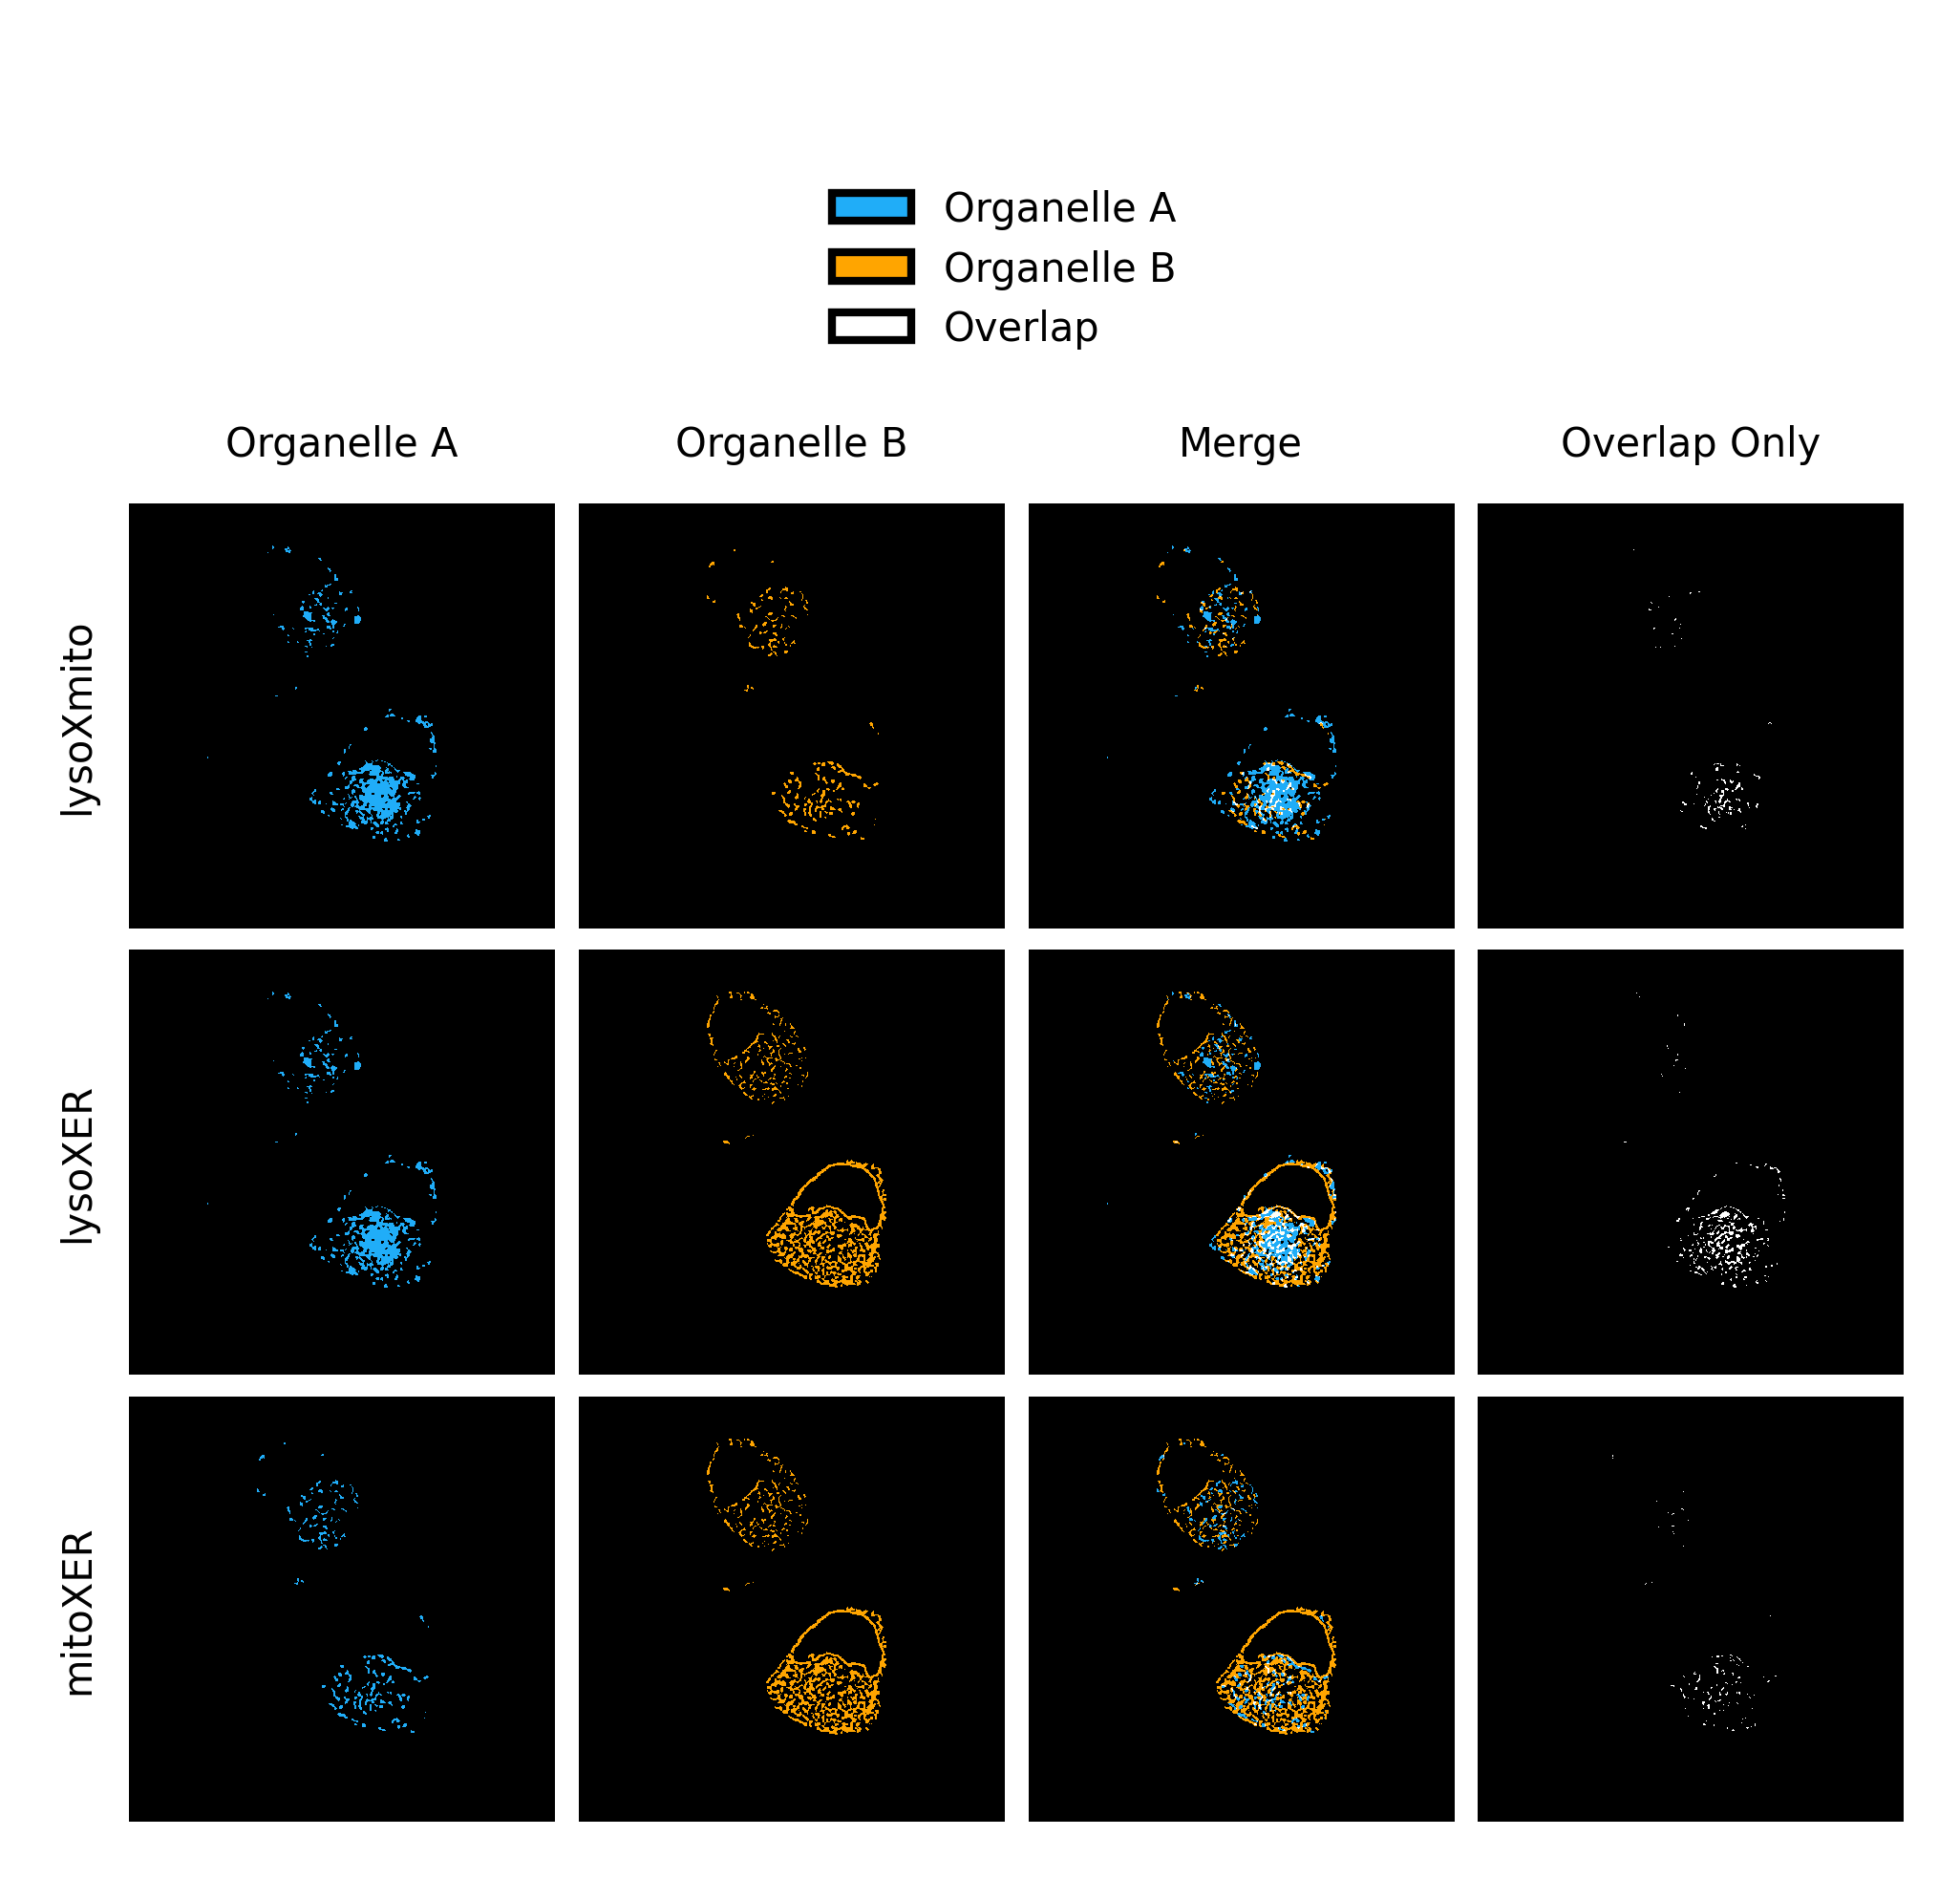

In [17]:
plot_overlaps(orgs=(orgs), splitter=splitter, organelle_segs=organelle_segs, scale=scale, close=True, holo=False)

## **`4` - Determine which nth order interactions are present in n+1 order interactions**

- adjust previous method for finding higher order contacts to work with nth order

In [18]:
LOc_NR = site.copy()                         
for org, val in organelle_segs.items():         
    if (org not in orgs.split(splitter)         #Proceeds if the organelle is not any of the orgs in nth order
        and np.any(overlap*val)):               
        digit = len(str(np.max(val)))           
        valid = (LOc_NR>0)*(val>0)              
        HOc = (LOc_NR*(10**(digit)))+val        
        HOc[valid.astype(bool)==False]=0        
        HOc = label(HOc)                        
        for id in np.unique(site[HOc > 0]):   
            LOc_NR[LOc_NR==id] = 0              

- create the function

In [19]:
def _find_non_redundant_overlaps(site: np.ndarray,
                                 orgs: str,
                                 organelle_segs: dict[str:np.ndarray],
                                 splitter: str="X"):
    ##########################################
    ## DETERMINE REDUNDANT OVERLAPS
    ##########################################
    LOc_NR = site.copy()                         
    for org, val in organelle_segs.items():         
        if (org not in orgs.split(splitter)
            and np.any(site*val)):
            print(f"Examining {orgs} Higher Order Interactions With {org}...", end="\r")               
            digit = len(str(np.max(val)))           
            valid = (LOc_NR>0)*(val>0)              
            HOc = (LOc_NR*(10**(digit)))+val        
            HOc[valid.astype(bool)==False]=0        
            HOc = label(HOc) 
            maxi = len(np.unique(LOc_NR[HOc>0]))                       
            for num, id in enumerate(np.unique(site[HOc > 0])):
                per = round((100*((num+1)/maxi)), 2)   
                LOc_NR[LOc_NR==id] = 0
                print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete", end="\r")
            print(f"Examining {orgs} Higher Order Interactionss With {org}: {per}% complete")     
    return LOc_NR

- visualize segmentations 'a', 'b', and 'c', their interactions, and their interactions not present in higher order interactions

# maroon = higher or lower order overlap
# white = total overlapping region

29-Jan-25 14:01:23 - vispy    - WARNING  - QWindowsWindow::setGeometry: Unable to set geometry 1920x1140+12+46 (frame: 1942x1196+1+1) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 1920x1050+12+46 (frame: 1942x1106+1+1) margins: 11, 45, 11, 11 minimum size: 385x491 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=792,1038 maxtrack=0,0)


Examining lysoXmito Higher Order Interactions With golgi: 100.0% complete
Examining lysoXmito Higher Order Interactions With perox: 100.0% complete
Examining lysoXmito Higher Order Interactions With ER: 100.0% complete
Examining lysoXmito Higher Order Interactions With LD: 100.0% complete


c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Examining lysoXER Higher Order Interactions With mito: 100.0% complete
Examining lysoXER Higher Order Interactions With golgi: 100.0% complete
Examining lysoXER Higher Order Interactions With perox: 100.0% complete
Examining lysoXER Higher Order Interactions With LD: 100.0% complete


c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


Examining mitoXER Higher Order Interactions With lyso: 100.0% complete
Examining mitoXER Higher Order Interactions With golgi: 100.0% complete
Examining mitoXER Higher Order Interactions With perox: 100.0% complete
Examining mitoXER Higher Order Interactions With LD: 100.0% complete


c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\zscoman\Anaconda3\envs\infer-subc\lib\site-packages\napari\utils\colormaps\colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


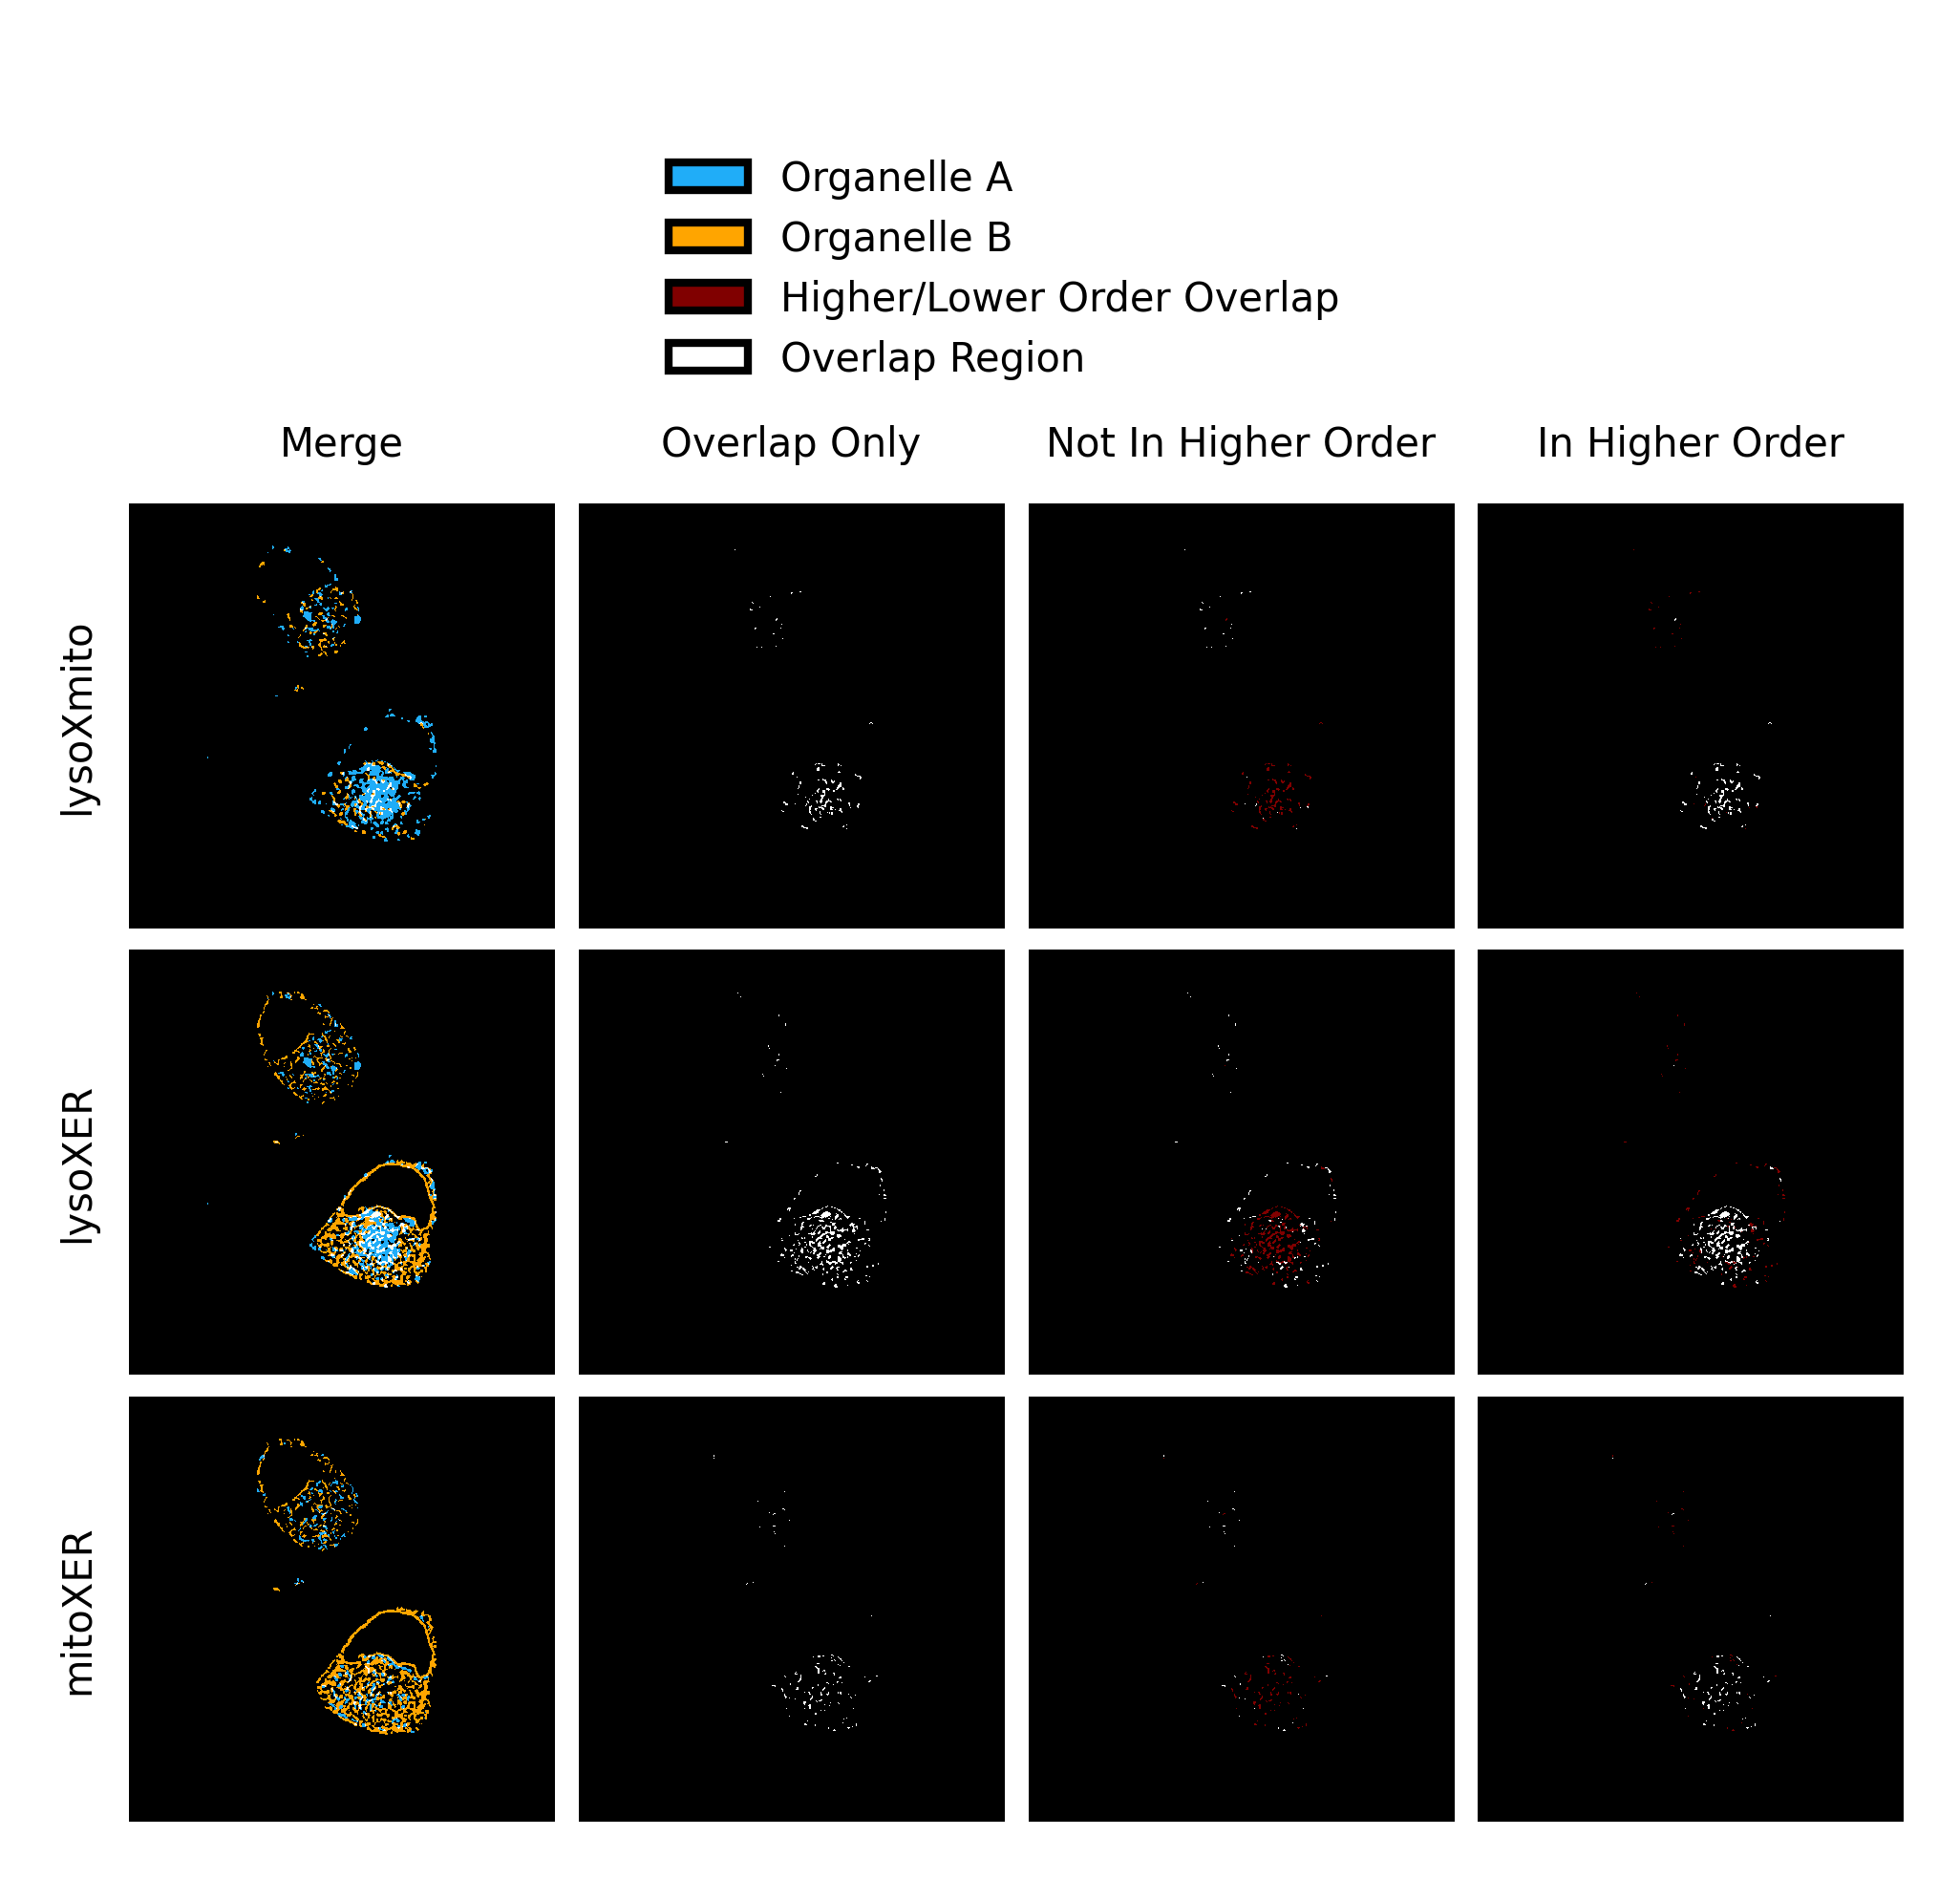

In [20]:
plot_overlaps(orgs=orgs, splitter=splitter, organelle_segs=organelle_segs, scale=scale)

In [ ]:
site = label(apply_mask(site, mask_img)).astype(int)

## **`5` - Build the list of measurements we want to include from regionprops and run regionprops**

- assemble list of measurements (morphological properties)

In [ ]:
# start with LABEL
test_Xproperties = ["label"]

# add position
test_Xproperties = test_Xproperties + ["centroid", "bbox"]

# add area
test_Xproperties = test_Xproperties + ["area", "equivalent_diameter"] # "num_pixels", 

# add shape measurements - NOTE: can't include minor axis measure because some of the interaction sites are only one pixel
test_Xproperties = test_Xproperties + ["extent", "euler_number", "solidity", "axis_major_length", "slice"] # "feret_diameter_max",  , "axis_minor_length"

- create initial regionprops table

In [ ]:
## NOTE: it may be worth our time to deal with the measurements that having issues with one voxel objects: 
## axis_min_length - the minimum axis of a voxel should be calulated as the minimum axis of a elipsoid with the same central moment as the voxel;
## when scaling this number should be calculated, but without scale, I think this would just be ~1

test_Xprops = regionprops_table(site, 
                                intensity_image=None, 
                                properties=test_Xproperties, 
                                extra_properties=None, 
                                spacing=scale)

In [ ]:
test_Xsurface_area_tab = pd.DataFrame(surface_area_from_props(site, test_Xprops, scale=scale))

## **`3` - Track which individual organelles are involved in that interaction**

- identify labels involved in each unique interaction

In [ ]:
inter_inv = []
involved = orgs.split(splitter)
indexes = dict.fromkeys(involved, [])
indexes[orgs] = []
for index, l in enumerate(test_Xprops["label"]):
    inter_inv.clear()
    for org in involved:
        volume = site[test_Xprops["slice"][index]]
        lorg = organelle_segs[org][test_Xprops["slice"][index]]
        volume = volume==l
        lorg = lorg[volume]                                 
        all_inv = np.unique(lorg[lorg>0]).tolist()          
        if len(all_inv) != 1:
            print(f"we have an error.  as-> {all_inv}")
        indexes[org].append(all_inv[0])
        inter_inv.append(f"{all_inv[0]}")
    indexes[orgs].append('_'.join(inter_inv))

- correct and add measurements

In [ ]:
props_table = pd.DataFrame(test_Xprops)
props_table.rename(columns={'label': 'idx'}, inplace=True)
props_table.drop(columns=['slice'], inplace=True)
props_table.insert(0, 'label',value=indexes[orgs])
props_table.insert(0, "object", orgs)
props_table.rename(columns={"area": "volume"}, inplace=True)
props_table.insert(11, "surface_area", test_Xsurface_area_tab)
props_table.insert(13, "SA_to_volume_ratio", 
props_table["surface_area"].div(props_table["volume"]))
if scale is not None:
    round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
    props_table.insert(loc=2, column="scale", value=f"{round_scale}")
else: 
    props_table.insert(loc=2, column="scale", value=f"{tuple(np.ones(site.ndim))}")

In [ ]:
props_table.head()

In [ ]:
LOc_NR = apply_mask((LOc_NR>0), mask_img).astype(int) * site
redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
fin_props_table = props_table.copy()
fin_props_table.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
fin_props_table.drop(columns=['idx'], inplace=True)

In [ ]:
fin_props_table.head()

<!-- #### `WIP`: Adding a "SHELL" measurement for each site of interaction, we want to measure the membrane surface area from each organelle involved in the interaction

I think the most logical way to do this seems to be using marching_cubes to create an isosurface of each object (org A, org B, and the intersection), then cut the orgs' isosurface using the overlap region. The isosurface region of intersection between the org and the overlap will be measured as the membrane in the interaction.

- **shell_aXb**: the "shell", or membrane, of organelle a overlapping with organelle b (*NOTE: shell_aXb and shellbXa are *NOT* redundant*) -->

# ***EXECUTE FUNCTION PROTOTYPE***

## **Define `_make_dict` function**

In [ ]:
def _make_dict(list_obj_names: list[str],
               list_obj_segs: list[np.ndarray]):
    organelle_segs = {}                                                     
    for idx, name in enumerate(list_obj_names):                                  
        if name == 'ER':                                                    
            organelle_segs[name]=(list_obj_segs[idx]>0).astype(np.uint16)        
        else:                                                       
            organelle_segs[name]=list_obj_segs[idx]
    return organelle_segs

## **Define `_all_combo` function**

In [ ]:
def _all_combo(list_obj_names: list[str], splitter: str="X"):
    all_pos = []
    for n in list(map(lambda x:x+2, (range(len(list_obj_names)-1)))):
        all_pos += itertools.combinations(list_obj_names, n)
    possib = [splitter.join(inter) for inter in all_pos]
    return possib

## **Define `_create_contact` function**

In [ ]:
def _create_overlap(orgs:str,
                    organelle_segs: dict[str:np.ndarray],
                    splitter: str="X") -> tuple[np.ndarray, np.ndarray]: 
    ##########################################
    ## CREATE OVERLAP
    ##########################################
    site = np.ones_like(organelle_segs[orgs.split(splitter)[0]])
    for org in orgs.split(splitter):
        b = organelle_segs[org]             
        valid = (b>0)*(site>0)
        digit = len(str(np.max(site)))      
        site = (b*(10**(digit)))+site       
        site[valid.astype(bool)==False]=0   
        site = label(site)             
    return site

## **Define `_find_non_redundant_contacts` function**

In [ ]:
def _find_non_redundant_overlaps(site: np.ndarray,
                                 orgs: str,
                                 organelle_segs: dict[str:np.ndarray],
                                 splitter: str="X"):
    ##########################################
    ## DETERMINE REDUNDANT OVERLAPS
    ##########################################
    LOc_NR = site.copy()                         
    for org, val in organelle_segs.items():         
        if (org not in orgs.split(splitter)
            and np.any(site*val)):
            print(f"Examining {orgs} Higher Order Interactions With {org}...", end="\r")               
            digit = len(str(np.max(val)))           
            valid = (LOc_NR>0)*(val>0)              
            HOc = (LOc_NR*(10**(digit)))+val        
            HOc[valid.astype(bool)==False]=0        
            HOc = label(HOc) 
            maxi = len(np.unique(LOc_NR[HOc>0]))                       
            for num, id in enumerate(np.unique(site[HOc > 0])):
                per = round((100*((num+1)/maxi)), 2)   
                LOc_NR[LOc_NR==id] = 0
                print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete", end="\r")
            print(f"Examining {orgs} Higher Order Interactions With {org}: {per}% complete")     
    return LOc_NR

## **Define `_contact_metric_analysis` function**

In [ ]:
def _interaction_metric_analysis(overlap_ID: str,
                                 list_obj_names: list[str],
                                 list_obj_segs: list[np.ndarray],
                                 mask: np.ndarray,
                                 splitter: str="X",
                                 scale: Union[tuple, None]=None,
                                 include_dist:bool=False, 
                                 dist_centering_obj: Union[np.ndarray, None]=None,
                                 dist_num_bins: Union[int, None]=None,
                                 dist_zernike_degrees: Union[int, None]=None,
                                 dist_center_on: Union[bool, None]=None,
                                 dist_keep_center_as_bin: Union[bool, None]=None,
                                 return_site: bool=False):
    """
    collect volumentric measurements of intersection between n organelle types

    Parameters
    ------------
    overlap_ID: str
        a value used to describe the organelles present in the overlap that can be divided by the splitter value
    org_dict: dict
        a dictionary of all object segmentations assigned to keys with their objects
    mask: np.ndarray
        3D (ZYX) binary mask of the area to measure interactions from
    splitter: str
        a value used to separate the overlap_ID to determine objects present in overlap
    scale: tuple
        a value present in the metadata determining the scale of the (ZYX) axis
    include_dist:bool=False
        *optional*
        True = include the XY and Z distribution measurements of the interaction sites within the masked region 
        (utilizing the functions get_XY_distribution() and get_Z_distribution() from Infer-subc)
        False = do not include distirbution measurements
    dist_centering_obj: Union[np.ndarray, None]=None
        ONLY NEEDED IF include_dist=True; if None, the center of the mask will be used
        3D (ZYX) np.ndarray containing the object to use for centering the XY distribution mask
    dist_num_bins: Union[int, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is 5
    dist_zernike_degrees: Unions[int, None]=None,
        ONLY NEEDED IF include_dist=True; if None, the zernike share measurements will not be included in the distribution
        the number of zernike degrees to include for the zernike shape descriptors
    dist_center_on: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is False
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    dist_keep_center_as_bin: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins


    Regionprops measurements:
    ------------------------
    ['label',
    'centroid',
    'bbox',
    'area',
    'equivalent_diameter',
    'extent',
    'feret_diameter_max',
    'euler_number',
    'convex_area',
    'solidity',
    'axis_major_length',
    'axis_minor_length']

    Additional measurements:
    ----------------------
    ['surface_area']

    
    Returns
    -------------
    pandas dataframe of containing regionprops measurements (columns) for each overlap region (rows)
    
    """
    #########################
    ## CREATE ORG_DICT
    #########################
    org_dict = _make_dict(list_obj_names, list_obj_segs)

    #########################
    ## CREATE OVERLAP REGIONS
    #########################
    # run create overlap function
    site = _create_overlap(overlap_ID, org_dict, splitter)

    #assert the nth order overlap to within the cellmask
    labels = label(apply_mask(site, mask)).astype(int)


    ##########################################
    ## CREATE LIST OF REGIONPROPS MEASUREMENTS
    ##########################################
    # start with LABEL
    properties = ["label"]

    # add position
    properties += ["centroid", "bbox"]

    # add area
    properties += ["area", "equivalent_diameter"] # "num_pixels", 

    # add shape measurements - NOTE: can't include minor axis measure because some of the contact sites are only one pixel
    properties += ["extent", "euler_number", "solidity", "axis_major_length", "slice"] # "feret_diameter_max",  , "axis_minor_length"
    

    ##################
    ## RUN REGIONPROPS
    ##################
    props = regionprops_table(labels, 
                              intensity_image=None, 
                              properties=properties, 
                              extra_properties=None, 
                              spacing=scale)

    ##################################################################
    ## RUN SURFACE AREA FUNCTION SEPARATELY AND APPEND THE PROPS_TABLE
    ##################################################################
    surface_area_tab = pd.DataFrame(surface_area_from_props(labels, props, scale))


    ########################################################
    ## LIST WHICH ORGANELLES ARE INVOLVED IN THE INTERACTION
    ########################################################
    inter_inv = []
    involved = overlap_ID.split(splitter)
    indexes = dict.fromkeys(involved, [])
    indexes[overlap_ID] = []

    for index, l in enumerate(props["label"]):
        inter_inv.clear()
        for org in involved:
            volume = labels[props["slice"][index]]
            lorg = org_dict[org][props["slice"][index]]
            volume = volume==l
            lorg = lorg[volume]                                 
            all_inv = np.unique(lorg[lorg>0]).tolist()          
            if len(all_inv) != 1:
                print(f"we have an error.  as-> {all_inv}")
            indexes[org].append(all_inv[0])
            inter_inv.append(f"{all_inv[0]}")
        indexes[overlap_ID].append('_'.join(inter_inv))

        
    ##################################################
    ## CREATE COMBINED DATAFRAME OF THE QUANTIFICATION
    ##################################################
    props_table = pd.DataFrame(props)
    props_table.rename(columns={'label': 'idx'}, inplace=True)
    props_table.drop(columns=['slice'], inplace=True)
    props_table.insert(0, 'label',value=indexes[overlap_ID])
    props_table.insert(0, "object", overlap_ID)
    props_table.rename(columns={"area": "volume"}, inplace=True)
    props_table.insert(11, "surface_area", surface_area_tab)
    props_table.insert(13, "SA_to_volume_ratio", 
    props_table["surface_area"].div(props_table["volume"]))
    if scale is not None:
        round_scale = (round(scale[0], 4), round(scale[1], 4), round(scale[2], 4))
        props_table.insert(loc=2, column="scale", value=f"{round_scale}")
    else: 
        props_table.insert(loc=2, column="scale", value=f"{tuple(np.ones(labels.ndim))}")


    ######################################################
    ## optional: DISTRIBUTION OF INTERACTION MEASUREMENTS
    ######################################################
    if include_dist:
        XY_interaction_dist, XY_bins, XY_wedges = get_XY_distribution(mask=mask, 
                                                                  obj=site,
                                                                  obj_name=overlap_ID,
                                                                  centering_obj=dist_centering_obj,
                                                                  scale=scale,
                                                                  center_on=dist_center_on,
                                                                  keep_center_as_bin=dist_keep_center_as_bin,
                                                                  num_bins=dist_num_bins,
                                                                  zernike_degrees=dist_zernike_degrees)
        
        Z_interaction_dist = get_Z_distribution(mask=mask,
                                            obj=site,
                                            obj_name=overlap_ID,
                                            center_obj=dist_centering_obj,
                                            scale=scale)
        interaction_dist_tab = pd.merge(XY_interaction_dist, Z_interaction_dist, on=["object", "scale"])

        indexes.clear()
        if return_site:
            return site, props_table, interaction_dist_tab
        else:
            return props_table, interaction_dist_tab
    else:
        indexes.clear()
        if return_site:
            return site, props_table
        else:
            return props_table

## **Define `_get_contact_metrics_3D` function**

Based on the _prototyping_ above define the function to quantify amount, size, and shape of organelles.

In [ ]:
def _get_interaction_metrics_3D(list_obj_names: list[str],
                                list_obj_segs: list[np.ndarray],
                                mask: np.ndarray,
                                splitter: str="X",
                                scale: Union[tuple, None]=None,
                                include_dist:bool=False, 
                                dist_centering_obj: Union[np.ndarray, None]=None,
                                dist_num_bins: Union[int, None]=None,
                                dist_zernike_degrees: Union[int, None]=None,
                                dist_center_on: Union[bool, None]=None,
                                dist_keep_center_as_bin: Union[bool, None]=None):
    """
    collect volumentric measurements of intersection between n, n+1, n+2... organelle types for an entire cell

    Parameters
    ------------
    list_obj_names: list
        a list of the names of objects used in making overlaps
    list_obj_segs: list
        a list of the segmentations of the objects used in making overlaps
    mask: np.ndarray
        3D (ZYX) binary mask of the area to measure overlaps from
    splitter: str="X"
        a value used to separate the organelles in their IDs
    scale: tuple
        3D (ZYX) assignment for the scaling of each axis
        include_dist:bool=False
        *optional*
        True = include the XY and Z distribution measurements of the interaction sites within the masked region 
        (utilizing the functions get_XY_distribution() and get_Z_distribution() from Infer-subc)
        False = do not include distirbution measurements
    dist_centering_obj: Union[np.ndarray, None]=None
        ONLY NEEDED IF include_dist=True; if None, the center of the mask will be used
        3D (ZYX) np.ndarray containing the object to use for centering the XY distribution mask
    dist_num_bins: Union[int, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is 5
    dist_zernike_degrees: Unions[int, None]=None,
        ONLY NEEDED IF include_dist=True; if None, the zernike share measurements will not be included in the distribution
        the number of zernike degrees to include for the zernike shape descriptors
    dist_center_on: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is False
        True = distribute the bins from the center of the centering object
        False = distribute the bins from the edge of the centering object
    dist_keep_center_as_bin: Union[bool, None]=None
        ONLY NEEDED IF include_dist=True; if None, the default is True
        True = include the centering object area when creating the bins
        False = do not include the centering object area when creating the bins

    Regionprops measurements:
    ------------------------
    ['label',
    'centroid',
    'bbox',
    'area',
    'equivalent_diameter',
    'extent',
    'feret_diameter_max',
    'euler_number',
    'convex_area',
    'solidity',
    'axis_major_length',
    'axis_minor_length']

    Additional measurements:
    ----------------------
    ['surface_area']

    
    Returns
    -------------
    pandas dataframe of containing regionprops measurements (columns) for each overlap region (rows)
    """

    ########################
    ## CREATE ORGANELLE DICT
    ########################
    organelle_segs = _make_dict(list_obj_names, list_obj_segs)                                                 
    
    #########################
    ## LIST POSSIBLE OVERLAPS
    #########################
    possib = _all_combo(list_obj_names, splitter)

    #######################
    ## ANALYZE ALL OVERLAPS
    #######################
    inter_tabs=[]
    dist_tabs=[]
    if include_dist:
        for inter in possib:
            inter_tab, dist_tab, site = _interaction_metric_analysis(overlap_ID=cont,
                                                                    list_obj_names=list_obj_names,
                                                                    list_obj_segs=list_obj_segs,
                                                                    org_dict=organelle_segs,
                                                                    mask=mask,
                                                                    splitter=splitter,
                                                                    scale=scale,
                                                                    include_dist=True,
                                                                    dist_centering_obj=dist_centering_obj,
                                                                    dist_num_bins=dist_num_bins,
                                                                    dist_zernike_degrees=dist_zernike_degrees,
                                                                    dist_center_on=dist_center_on,
                                                                    dist_keep_center_as_bin=dist_keep_center_as_bin,
                                                                    return_site=True)
            LOc_NR = _find_non_redundant_overlaps(site, inter, organelle_segs, splitter)
            LOc_NR = apply_mask((LOc_NR>0), mask).astype(int) * site
            redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
            inter_tab.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
            inter_tab.drop(columns=['idx'], inplace=True)
            inter_tabs.append(inter_tab)
            dist_tabs.append(dist_tab)
        return inter_tabs, dist_tabs
    else:
        for inter in possib:
            inter_tab, site = _interaction_metric_analysis(overlap_ID=inter,
                                                          org_dict=organelle_segs,
                                                          mask=mask,
                                                          splitter=splitter,
                                                          scale=scale,
                                                          include_dist=False,
                                                          return_site=True)
            LOi_NR = _find_non_redundant_overlaps(site, inter, organelle_segs, splitter)
            LOi_NR = apply_mask((LOi_NR>0), mask).astype(int) * site
            redundancy = props_table['idx'].isin(np.unique(LOc_NR[LOc_NR>0]).tolist())
            inter_tab.insert(2, "in_higher_order", list(map(bool, ~redundancy)))
            inter_tab.drop(columns=['idx'], inplace=True)
            inter_tabs.append(inter_tab)
        return inter_tabs

## **Run `_get_contact_metrics_3D` function (scaled)**

In [ ]:
stat_tab_test, test_inter_dist_tab = _interaction_metric_analysis(overlap_ID=orgs,
                                                                 list_obj_names=org_names,
                                                                 list_obj_segs=org_segs,
                                                                 mask=region_segs[region_names.index("cell")], 
                                                                 scale=scale,
                                                                 include_dist=True, 
                                                                 dist_centering_obj=region_segs[region_names.index("nuc")],
                                                                 dist_center_on=False,
                                                                 dist_keep_center_as_bin=True,
                                                                 dist_num_bins=5,
                                                                 dist_zernike_degrees=9)

stat_tab_test.equals(props_table)

In [ ]:
test_inter_dist_tab

## **Compare to finalized `get_contact_metrics_3D` function**

In [ ]:
from infer_subc.utils.stats import interaction_metric_analysis

test_stat_tab_final, test_inter_dist_tab_final = interaction_metric_analysis(overlap_ID=orgs, 
                                                                            list_obj_names=org_names,
                                                                            list_obj_segs=org_segs,
                                                                            mask=region_segs[region_names.index("cell")], 
                                                                            scale=scale,
                                                                            include_dist=True, 
                                                                            dist_centering_obj=region_segs[region_names.index("nuc")],
                                                                            dist_center_on=False,
                                                                            dist_keep_center_as_bin=True,
                                                                            dist_num_bins=5,
                                                                            dist_zernike_degrees=9)

stat_tab_test.equals(test_stat_tab_final), test_inter_dist_tab.equals(test_inter_dist_tab_final)